# 🌟 Machine Learning Practice Notebook
## Simple, Step-by-Step Examples

---

**Welcome!** 

This notebook is your practice ground. We are going to walk through the core machine learning steps using **simple, real datasets** - Please don't be overwhelmed by the codes, there's no confusion, just clear steps!

We have **two examples** in this notebook:

| Example | Type | Dataset |
|---------|------|---------|
| 🌸 Example 1 | **Classification** — predicting a category | Iris Flowers |
| 🏠 Example 2 | **Regression** — predicting a number | Tips / Spending |

---

### 📌 The Machine Learning Steps (We follow these EVERY time!)

```
Step 1️⃣  → Load the data
Step 2️⃣  → Explore the data
Step 3️⃣  → Prepare the data (features X and target y)
Step 4️⃣  → Split: Training set vs Testing set
Step 5️⃣  → Train the model
Step 6️⃣  → Make predictions
Step 7️⃣  → Evaluate the model
```

---

> 📚 **Want to go deeper?** After this notebook, open `ml_workbook.ipynb` in this same folder for detailed explanations, real-world Kenyan data, and optimization techniques!

---
## 📦 First: Import the Tools We Need

Think of this like packing your school bag before class — you need the right tools before you start!

In [1]:
# 📦 Import all the libraries we need for this notebook

import seaborn as sns                          # For loading datasets and plotting
import pandas as pd                            # For working with tables of data
import matplotlib.pyplot as plt               # For drawing charts

# Scikit-learn — the main machine learning library
from sklearn.model_selection import train_test_split   # Split data into train/test
from sklearn.preprocessing import LabelEncoder         # Turn text labels into numbers

# Classification model
from sklearn.neighbors import KNeighborsClassifier     # KNN — our classification model
from sklearn.metrics import accuracy_score, classification_report  # Evaluate classification

# Regression model
from sklearn.linear_model import LinearRegression      # Linear Regression model
from sklearn.metrics import mean_absolute_error, r2_score  # Evaluate regression

print('✅ All tools loaded successfully!')

✅ All tools loaded successfully!


---
---
# 🌸 EXAMPLE 1: Classification
## "Can we identify a flower species by its measurements?"

---

### 🌻 The Story

Imagine **Akinyi** is a biology student at **Maseno University**. She is out in the field collecting flower samples. She measures each flower (petal length, petal width, etc.) and wants to know:

> *"Given these measurements, what species is this flower?"*

This is a **classification problem** — we are predicting a **category** (which species), not a number.

**The 3 flower species (classes) we will predict:**

| Class | Flower Name |
|-------|-------------|
| 0 | Setosa |
| 1 | Versicolor |
| 2 | Virginica |

---

### 🔢 The 4 Features (measurements) Akinyi records:
- `sepal_length` — length of the outer part of the flower
- `sepal_width` — width of the outer part
- `petal_length` — length of the inner petal
- `petal_width` — width of the inner petal

### Step 1️⃣ — Load the Data

In [2]:
# Step 1: Load the Iris dataset (it comes built-in with seaborn — no file needed!)
iris = sns.load_dataset('iris')

# Show the first 5 rows — like peeking at the first page of Akinyi's notebook
print('Shape of dataset:', iris.shape)   # (rows, columns)
iris.head()

Shape of dataset: (150, 5)


,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


### Step 2️⃣ — Explore the Data

In [3]:
# Step 2a: How many flowers of each species do we have?
print('🌸 Count of each flower species:')
print(iris['species'].value_counts())

🌸 Count of each flower species:
species
setosa        50
versicolor    50
virginica     50
Name: count, dtype: int64


In [4]:
# Step 2b: Quick summary of the numbers
iris.describe()

,sepal_length,sepal_width,petal_length,petal_width
count,150.000000,150.000000,150.000000,150.000000
mean,5.843333,3.057333,3.758000,1.199333
std,0.828066,0.435866,1.765298,0.762238
min,4.300000,2.000000,1.000000,0.100000
25%,5.100000,2.800000,1.600000,0.300000
50%,5.800000,3.000000,4.350000,1.300000
75%,6.400000,3.300000,5.100000,1.800000
max,7.900000,4.400000,6.900000,2.500000


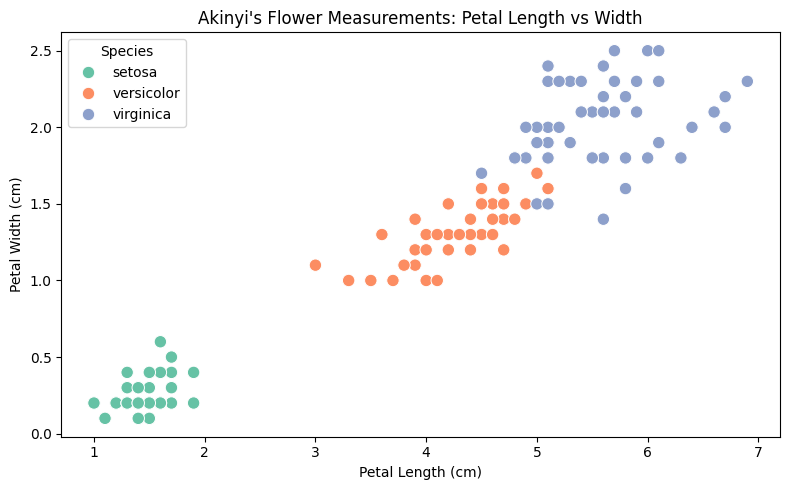

In [5]:
# Step 2c: Visualise — do the different species look different when we plot petal measurements?
plt.figure(figsize=(8, 5))
sns.scatterplot(data=iris, x='petal_length', y='petal_width', hue='species', palette='Set2', s=80)
plt.title("Akinyi's Flower Measurements: Petal Length vs Width")
plt.xlabel('Petal Length (cm)')
plt.ylabel('Petal Width (cm)')
plt.legend(title='Species')
plt.tight_layout()
plt.show()

# 💬 Notice how the 3 groups form separate clusters? That's what the model will learn!

### Step 3️⃣ — Prepare the Data: Features (X) and Target (y)

> 📌 **X** = the inputs (measurements the model learns FROM)  
> 📌 **y** = the answer we want to predict (the species name)

We also need to convert the species names (text) into numbers, because ML models only understand numbers!

In [6]:
# Step 3: Separate features (X) from the target (y)

X = iris[['sepal_length', 'sepal_width', 'petal_length', 'petal_width']]  # inputs
y_text = iris['species']                                                     # output (text)

# Convert text species names → numbers  (setosa=0, versicolor=1, virginica=2)
encoder = LabelEncoder()
y = encoder.fit_transform(y_text)

print('Features (X) — first 3 rows:')
print(X.head(3))
print()
print('Target (y) — first 10 values:', y[:10])
print('What the numbers mean:', encoder.classes_)   # 0=setosa, 1=versicolor, 2=virginica

Features (X) — first 3 rows:
   sepal_length  sepal_width  petal_length  petal_width
0           5.1          3.5           1.4          0.2
1           4.9          3.0           1.4          0.2
2           4.7          3.2           1.3          0.2

Target (y) — first 10 values: [0 0 0 0 0 0 0 0 0 0]
What the numbers mean: ['setosa' 'versicolor' 'virginica']


### Step 4️⃣ — Split into Training Set and Testing Set

> 📌 Think of it like this: Akinyi studies from **past exam papers (training data)**, then she sits a **mock exam she has never seen (test data)**. We check her score on the mock to know if she really understands.

We use **80% for training** and **20% for testing**.

In [7]:
# Step 4: Split the data
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,      # 20% goes to testing
    random_state=42     # 42 = fixed seed so we get the same split every time
)

print(f'Training samples:  {len(X_train)}  (the model learns from these)')
print(f'Testing samples:   {len(X_test)}   (we check the model on these)')

Training samples:  120  (the model learns from these)
Testing samples:   30   (we check the model on these)


### Step 5️⃣ — Train the Model

We will use **K-Nearest Neighbors (KNN)** — a simple model that says:
> *"Look at the 3 most similar flowers I've seen before. What species were they? I'll guess the same!"*

In [8]:
# Step 5: Create and train the model
model_clf = KNeighborsClassifier(n_neighbors=3)   # Look at 3 nearest neighbours
model_clf.fit(X_train, y_train)                   # .fit() = train the model!

print('✅ Model trained! Akinyi\'s flower identifier is ready.')

✅ Model trained! Akinyi's flower identifier is ready.


### Step 6️⃣ — Make Predictions

In [9]:
# Step 6: Use the trained model to predict on the test set
y_pred_clf = model_clf.predict(X_test)

# Show first 10 predictions vs actual answers
results = pd.DataFrame({
    'Actual':    encoder.inverse_transform(y_test[:10]),   # convert numbers back to names
    'Predicted': encoder.inverse_transform(y_pred_clf[:10])
})

print('📊 First 10 Predictions:')
print(results.to_string(index=False))

📊 First 10 Predictions:
    Actual  Predicted
versicolor versicolor
    setosa     setosa
 virginica  virginica
versicolor versicolor
versicolor versicolor
    setosa     setosa
versicolor versicolor
 virginica  virginica
versicolor versicolor
versicolor versicolor


### Step 7️⃣ — Evaluate the Model

> 📌 **Accuracy** = out of all predictions, what percentage were correct?
> 
> An accuracy of **0.95 = 95%** — the model got 95 out of every 100 correct!

In [10]:
# Step 7: Evaluate — how well did the model do?
accuracy = accuracy_score(y_test, y_pred_clf)
print(f'🎯 Accuracy: {accuracy:.2%}')   # e.g. 96.67%

print()
print('📋 Full Report:')
print(classification_report(y_test, y_pred_clf, target_names=encoder.classes_))

🎯 Accuracy: 100.00%

📋 Full Report:
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       1.00      1.00      1.00         9
   virginica       1.00      1.00      1.00        11

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30



### 🧪 Try It Yourself — Predict a New Flower!

Akinyi found a new flower. She measured it:
- sepal_length = **5.1**, sepal_width = **3.5**, petal_length = **1.4**, petal_width = **0.2**

What species is it?

In [11]:
# 🧪 Predict a brand new flower — one the model has NEVER seen before!
new_flower = [[5.1, 3.5, 1.4, 0.2]]   # [sepal_length, sepal_width, petal_length, petal_width]

prediction = model_clf.predict(new_flower)
species_name = encoder.inverse_transform(prediction)[0]

print(f'🌸 Akinyi\'s new flower is predicted to be: {species_name.upper()}')

🌸 Akinyi's new flower is predicted to be: SETOSA


c:\Users\THINKPAD\Desktop\ccub_Ai_for_teens_bootcamp\mnotes\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but KNeighborsClassifier was fitted with feature names
  warnings.warn(


### 💬 Mini Activity — Change the flower measurements above and re-run!
Try:
- `[6.5, 3.0, 5.2, 2.0]` — what species comes out?
- `[5.8, 2.7, 4.1, 1.0]` — and this one?

---
---
# ✅ Example 1 Summary

| Step | What we did |
|------|-------------|
| Load | Loaded the Iris dataset |
| Explore | Counted species, plotted a scatter chart |
| Prepare | Split X (features) and y (target), encoded labels |
| Split | 80% train, 20% test |
| Train | KNeighborsClassifier with n_neighbors=3 |
| Predict | Used `.predict()` on test data |
| Evaluate | Checked accuracy and classification report |

> 🔗 **Go deeper:** Open `ml_workbook.ipynb` → Section 5 (Training a Model) and Section 6 (Evaluating the Model) for detailed explanations and real-world practice with Kenyan student data!

---
---
# 🍽️ EXAMPLE 2: Regression
## "Can we predict how much someone will spend based on their bill?"

---

### 🍛 The Story

**Kamau** works at a popular restaurant in **Nairobi CBD** called *Mama Oliech's*. He wants to understand tipping patterns:

> *"If I know the total bill, the day, and the group size — can I predict how much tip the customer will leave?"*

This is a **regression problem** — we are predicting a **number** (the tip amount), not a category.

---

### 📊 The Dataset (Tips)
Seaborn has a built-in `tips` dataset. Each row is one customer's visit:

| Column | Meaning |
|--------|---------|
| `total_bill` | The total food bill (KES equivalent) |
| `tip` | The tip left (what we want to predict!) |
| `size` | Number of people at the table |
| `day` | Day of the week |
| `time` | Lunch or Dinner |

### Step 1️⃣ — Load the Data

In [12]:
# Step 1: Load the Tips dataset (also built into seaborn)
tips = sns.load_dataset('tips')

print('Shape:', tips.shape)
tips.head()

Shape: (244, 7)


,total_bill,tip,sex,smoker,day,time,size
0,16.99,1.01,Female,No,Sun,Dinner,2
1,10.34,1.66,Male,No,Sun,Dinner,3
2,21.01,3.50,Male,No,Sun,Dinner,3
3,23.68,3.31,Male,No,Sun,Dinner,2
4,24.59,3.61,Female,No,Sun,Dinner,4


### Step 2️⃣ — Explore the Data

In [13]:
# Step 2a: Quick summary
tips.describe()

,total_bill,tip,size
count,244.000000,244.000000,244.000000
mean,19.785943,2.998279,2.569672
std,8.902412,1.383638,0.951100
min,3.070000,1.000000,1.000000
25%,13.347500,2.000000,2.000000
50%,17.795000,2.900000,2.000000
75%,24.127500,3.562500,3.000000
max,50.810000,10.000000,6.000000


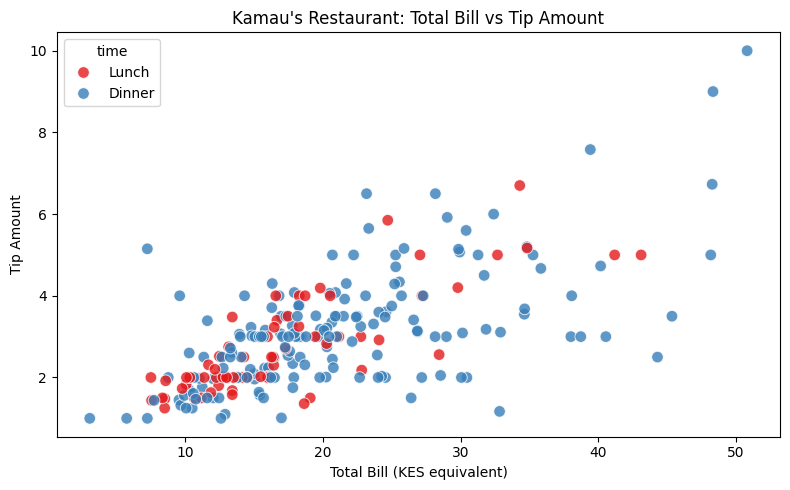

In [14]:
# Step 2b: Does a bigger bill mean a bigger tip? Let's plot it!
plt.figure(figsize=(8, 5))
sns.scatterplot(data=tips, x='total_bill', y='tip', hue='time', palette='Set1', s=70, alpha=0.8)
plt.title("Kamau's Restaurant: Total Bill vs Tip Amount")
plt.xlabel('Total Bill (KES equivalent)')
plt.ylabel('Tip Amount')
plt.tight_layout()
plt.show()

# 💬 You can see: bigger bills generally get bigger tips. There's a pattern — the model will learn it!

### Step 3️⃣ — Prepare the Data

For simplicity, we will use **only `total_bill` and `size`** as our features.
Our target is **`tip`**.

In [15]:
# Step 3: Pick features (X) and target (y)
X_tips = tips[['total_bill', 'size']]   # 2 features — the bill and group size
y_tips = tips['tip']                    # target — the tip amount we want to predict

print('Features (X):')
print(X_tips.head(4))
print()
print('Target (y) — first 4 values:')
print(y_tips.head(4).values)

Features (X):
   total_bill  size
0       16.99     2
1       10.34     3
2       21.01     3
3       23.68     2

Target (y) — first 4 values:
[1.01 1.66 3.5  3.31]


### Step 4️⃣ — Split into Training and Testing Sets

In [16]:
# Step 4: Split the data — 80% train, 20% test
X_train_t, X_test_t, y_train_t, y_test_t = train_test_split(
    X_tips, y_tips,
    test_size=0.2,
    random_state=42
)

print(f'Training samples: {len(X_train_t)}')
print(f'Testing samples:  {len(X_test_t)}')

Training samples: 195
Testing samples:  49


### Step 5️⃣ — Train the Model

We use **Linear Regression** — the simplest regression model.

> 📌 Linear Regression draws the best straight line through the data points. Then it uses that line to predict future values.

In [17]:
# Step 5: Create and train the Linear Regression model
model_reg = LinearRegression()
model_reg.fit(X_train_t, y_train_t)    # .fit() = learn the pattern!

print('✅ Model trained!')
print(f'   The model found this formula:')
print(f'   tip ≈ {model_reg.coef_[0]:.3f} × total_bill  +  {model_reg.coef_[1]:.3f} × size  +  {model_reg.intercept_:.3f}')

✅ Model trained!
   The model found this formula:
   tip ≈ 0.091 × total_bill  +  0.265 × size  +  0.568


### Step 6️⃣ — Make Predictions

In [18]:
# Step 6: Predict tip amounts on the test set
y_pred_reg = model_reg.predict(X_test_t)

# Show first 8 predictions vs actual tips
comparison = pd.DataFrame({
    'Actual Tip':    y_test_t.values[:8].round(2),
    'Predicted Tip': y_pred_reg[:8].round(2),
    'Difference':    (y_test_t.values[:8] - y_pred_reg[:8]).round(2)
})

print('📊 Actual vs Predicted Tips (first 8):')
print(comparison.to_string(index=False))

📊 Actual vs Predicted Tips (first 8):
 Actual Tip  Predicted Tip  Difference
       3.18           2.90        0.28
       2.00           1.90        0.10
       2.00           3.86       -1.86
       5.16           3.98        1.18
       2.00           2.28       -0.28
       2.00           2.72       -0.72
       2.56           3.68       -1.12
       2.52           2.23        0.29


### Step 7️⃣ — Evaluate the Model

For regression, we don't use accuracy. We use:

| Metric | Meaning |
|--------|---------|
| **MAE** (Mean Absolute Error) | On average, how many units off are our predictions? Lower = better |
| **R² Score** | How well does the model explain the data? Range: 0 to 1 — closer to 1 = better |

In [19]:
# Step 7: Evaluate the regression model
mae = mean_absolute_error(y_test_t, y_pred_reg)
r2  = r2_score(y_test_t, y_pred_reg)

print(f'📉 Mean Absolute Error (MAE): {mae:.2f}')
print(f'   → On average, our tip prediction is off by {mae:.2f} units')
print()
print(f'📈 R² Score: {r2:.2f}')
print(f'   → The model explains {r2*100:.1f}% of the variation in tips')

📉 Mean Absolute Error (MAE): 0.66
   → On average, our tip prediction is off by 0.66 units

📈 R² Score: 0.48
   → The model explains 48.1% of the variation in tips


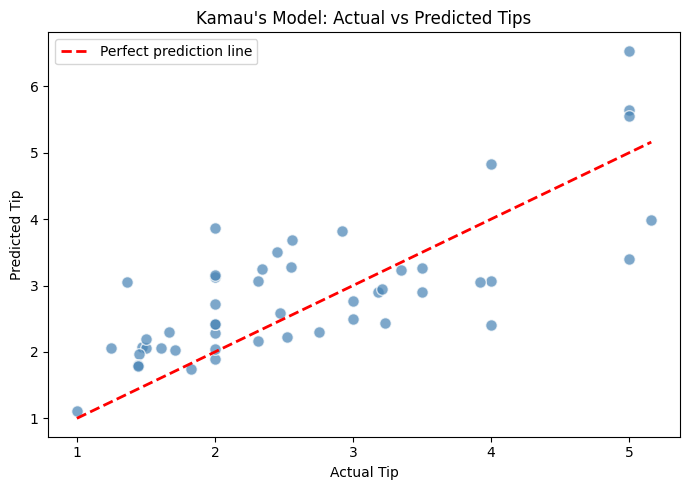

In [20]:
# Visualise predictions vs actual values
plt.figure(figsize=(7, 5))
plt.scatter(y_test_t, y_pred_reg, color='steelblue', alpha=0.7, edgecolors='white', s=70)
plt.plot([y_test_t.min(), y_test_t.max()],
         [y_test_t.min(), y_test_t.max()],
         'r--', linewidth=2, label='Perfect prediction line')
plt.xlabel('Actual Tip')
plt.ylabel('Predicted Tip')
plt.title("Kamau's Model: Actual vs Predicted Tips")
plt.legend()
plt.tight_layout()
plt.show()

# 💬 Points close to the red dashed line = great predictions!

### 🧪 Try It Yourself — Predict a Real Customer!

A table of **4 people** at Mama Oliech's just finished eating. Their total bill is **Ksh 850** (about 22 in dataset units). How much tip will they leave?

In [ ]:
# 🧪 Predict tip for a new customer
# Format: [[total_bill, size]]
new_customer = [[22.0, 4]]   # Bill = 22, Group size = 4

predicted_tip = model_reg.predict(new_customer)[0]
print(f'🍽️  Predicted tip for Kamau\'s customer: {predicted_tip:.2f}')

### 💬 Mini Activity — Change the values above and re-run!
Try:
- A bill of `35.0` with `2` people — does the tip go up or down?
- A bill of `10.0` with `1` person — what is predicted?

---
---
# ✅ Example 2 Summary

| Step | What we did |
|------|-------------|
| Load | Loaded the Tips dataset |
| Explore | Summary stats, scatter plot |
| Prepare | Selected total_bill and size as features, tip as target |
| Split | 80% train, 20% test |
| Train | LinearRegression model |
| Predict | Used `.predict()` to estimate tips |
| Evaluate | Checked MAE and R² Score |

> 🔗 **Go deeper:** Open `ml_workbook.ipynb` → Section 6 (Evaluating Models) and Section 7 (Model Optimization) to learn how to improve these models and apply them to real Kenyan student data!

---
---
# 🏁 Quick Comparison: Classification vs Regression

| | Classification (Example 1) | Regression (Example 2) |
|--|---------------------------|------------------------|
| **Question** | What *category* is this? | What *number* will this be? |
| **Answer type** | A label (setosa, pass/fail) | A number (3.5, 250) |
| **Model used** | KNeighborsClassifier | LinearRegression |
| **Main metric** | Accuracy (%) | MAE, R² Score |
| **Example** | Is this flower setosa or not? | How much tip will this customer leave? |

---

## 🚀 What's Next?

You have now completed the basics of machine learning! Here is your learning path:

```
✅  This notebook  →  You understand the steps!
     ↓
📖  ml_workbook.ipynb  →  Deeper explanations + real Kenyan student data
                          + Data scaling + Model optimization (Grid Search)
```

### 🎯 Key Things to Remember

1. **Always split** your data into train and test — never test on data the model was trained on
2. **Features (X)** are inputs; **Target (y)** is what you're trying to predict
3. **Classification** = predicting a category; **Regression** = predicting a number
4. **Accuracy** is for classification; **MAE and R²** are for regression
5. `.fit()` = train the model; `.predict()` = use the model

---
*Practice notebook — CCUB AI for Teens Bootcamp*